In [22]:
import pandas as pd

DATA_FILE = r'D:\LLM\techblog-summarize\data\all_crawled_data\DATA-all_crawled_articles_with_md_20251024_165234.csv'
df = pd.read_csv(DATA_FILE)

df.head()

,name,link,tags,markdown,summary
0,VIBLO MOBILE APP CHÍNH THỨC RA MẮT – TRẢI NGHI...,https://viblo.asia/announcements/viblo-mobile-...,[],NaN,NaN
1,Padding trong struct,https://viblo.asia/p/padding-trong-struct-kY4g...,['C/Cpp'],Xem ví dụ sau đây: Viết một struct message_t đ...,Giải thích hiện tượng padding trong struct của...
2,"Saudi Arabia AI: Understanding Its Types, and ...",https://viblo.asia/p/saudi-arabia-ai-understan...,"['Artificial Intelligence', 'Saudi Arabia Ai']",Everybody agrees that artificial intelligence ...,"AI tại Ả Rập Saudi đang phát triển mạnh, với t..."
3,Hướng dẫn tạo TLS Cetificiate Fullchain Self-s...,https://viblo.asia/p/huong-dan-tao-tls-cetific...,['Cài đặt SSL'],Thời gian gần đây mình có setup 1 vài hệ thống...,Bài viết hướng dẫn cách tạo chuỗi chứng chỉ SS...
4,Tạo component React Markdown Preview và Publis...,https://viblo.asia/p/tao-component-react-markd...,"['Markdown', 'npm']",Xây dựng 1 package render markdown thành jsx đ...,"Bài viết mô tả trọn vẹn cách tự xây dựng, đóng..."


In [23]:
# Delete rows with missing markdown column
df = df.dropna(subset=['markdown'])
df.head()

,name,link,tags,markdown,summary
1,Padding trong struct,https://viblo.asia/p/padding-trong-struct-kY4g...,['C/Cpp'],Xem ví dụ sau đây: Viết một struct message_t đ...,Giải thích hiện tượng padding trong struct của...
2,"Saudi Arabia AI: Understanding Its Types, and ...",https://viblo.asia/p/saudi-arabia-ai-understan...,"['Artificial Intelligence', 'Saudi Arabia Ai']",Everybody agrees that artificial intelligence ...,"AI tại Ả Rập Saudi đang phát triển mạnh, với t..."
3,Hướng dẫn tạo TLS Cetificiate Fullchain Self-s...,https://viblo.asia/p/huong-dan-tao-tls-cetific...,['Cài đặt SSL'],Thời gian gần đây mình có setup 1 vài hệ thống...,Bài viết hướng dẫn cách tạo chuỗi chứng chỉ SS...
4,Tạo component React Markdown Preview và Publis...,https://viblo.asia/p/tao-component-react-markd...,"['Markdown', 'npm']",Xây dựng 1 package render markdown thành jsx đ...,"Bài viết mô tả trọn vẹn cách tự xây dựng, đóng..."
5,Deploy Laravel Project lên VPS với Github Actions,https://viblo.asia/p/deploy-laravel-project-le...,"['Github Actions', 'Laravel']",Bài viết này không đề cập đến khái niệm CI/CD....,Hướng dẫn ngắn gọn cách deploy một dự án Larav...


# Analyzing

In [24]:
def md_to_text(md: str, remove_code_block: bool, remove_list_indicator: bool) -> str:
    """Convert markdown to plain text by removing markdown syntax.

    Args:
        md (str): The markdown content.
        remove_code_block (bool): Whether to remove code blocks.
        remove_list_indicator (bool): Whether to remove list indicators.
    Returns:
        str: The plain text content.
    """
    # Types of md included in the original text: #, ##, ###, ```, but keep the list indicator like - or [num].
    import re
    # Remove code blocks if specified
    if remove_code_block:
        # Remove all code blocks enclosed in triple backticks
        md = re.sub(r'```.*?```', '', md, flags=re.DOTALL)
    # Remove markdown headers, but keep the text
    md = re.sub(r'#+ ', '', md)
    # Remove inline code enclosed in single backticks
    md = re.sub(r'`(.*?)`', r'\1', md)
    # Remove bold and italic markers
    md = re.sub(r'\*\*(.*?)\*\*', r'\1', md)
    md = re.sub(r'\*(.*?)\*', r'\1', md)
    if remove_list_indicator:
        # Remove unordered list indicators like - or *
        md = re.sub(r'^\s*[-*]\s+', '', md, flags=re.MULTILINE)
        # Remove ordered list indicators like 1., 2., etc.
        md = re.sub(r'^\s*\d+\.\s+', '', md, flags=re.MULTILINE)
    # Remove all the links
    md = re.sub(r'\[(.*?)\]\(.*?\)', r'\1', md)
    return md

def identify_language(text: str) -> str:
    """Identify the language of the given text using langdetect.

    Args:
        text (str): The input text.
    Returns:
        str: The detected language code (e.g., 'en' for English).
    """
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0  # For consistent results
    try:
        language = detect(text)
    except:
        language = 'unknown'
    return language


# Distributions


In [25]:
plain_texts = [md_to_text(md, remove_code_block=True, remove_list_indicator=True) for md in df['markdown']]
languages = [identify_language(text) for text in plain_texts]
plain_word_counts = [len(text.split()) for text in plain_texts]
summary_word_counts = [len(summary.split()) for summary in df['summary']]

print('Numbers of articles:', len(df))
print('Language distribution:')
from collections import Counter
language_counts = Counter(languages)
for lang, count in language_counts.items():
    print(f'  {lang}: {count} articles')
print('Average word count in plain text articles:', sum(plain_word_counts) / len(plain_word_counts))
print('Average word count in summaries:', sum(summary_word_counts) / len(summary_word_counts))

Numbers of articles: 297
Language distribution:
  vi: 259 articles
  en: 38 articles
Average word count in plain text articles: 1242.3838383838383
Average word count in summaries: 117.3063973063973


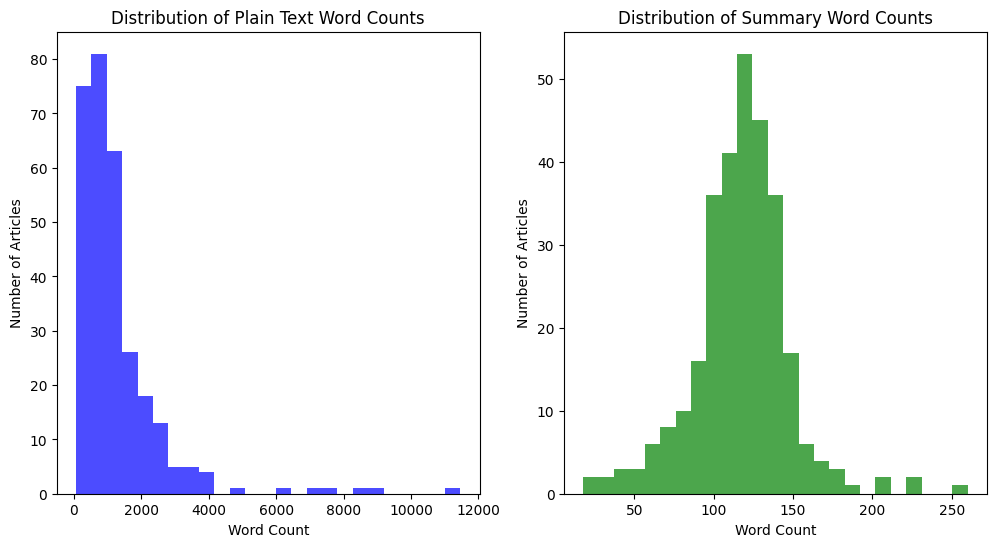

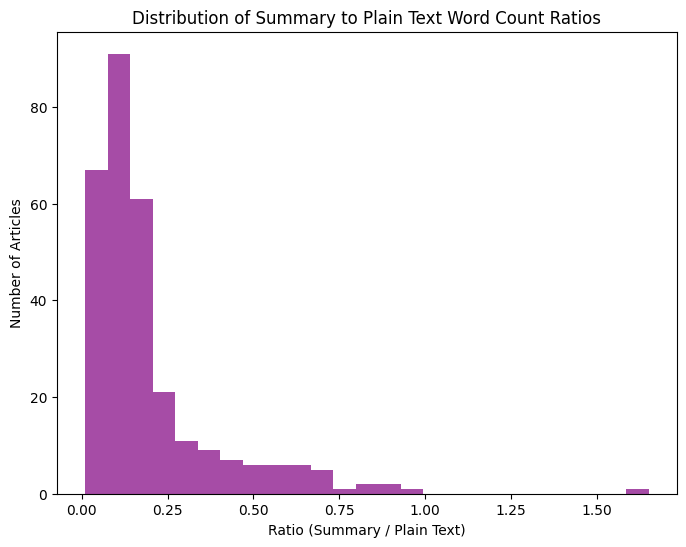

In [26]:
def distribution(plain_word_coutns: list, summary_word_counts: list, languages: list):
    """Plot the distribution of word counts for plain texts and summaries. Draw using matplotlib"""
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].hist(plain_word_coutns, bins=25, color='blue', alpha=0.7)
    ax[0].set_title('Distribution of Plain Text Word Counts')
    ax[0].set_xlabel('Word Count')
    ax[0].set_ylabel('Number of Articles')
    ax[1].hist(summary_word_counts, bins=25, color='green', alpha=0.7)
    ax[1].set_title('Distribution of Summary Word Counts')
    ax[1].set_xlabel('Word Count')
    ax[1].set_ylabel('Number of Articles')
    plt.show()

def ratio_plot(plain_word_counts: list, summary_word_counts: list):
    """Plot the ratio of summary word count to plain text word count."""
    import matplotlib.pyplot as plt
    import numpy as np

    ratios = [s / p if p > 0 else 0 for p, s in zip(plain_word_counts, summary_word_counts)]
    plt.figure(figsize=(8, 6))
    plt.hist(ratios, bins=25, color='purple', alpha=0.7)
    plt.title('Distribution of Summary to Plain Text Word Count Ratios')
    plt.xlabel('Ratio (Summary / Plain Text)')
    plt.ylabel('Number of Articles')
    plt.show()


distribution(plain_word_counts, summary_word_counts, languages)
ratio_plot(plain_word_counts, summary_word_counts)

In [27]:
def is_extractive(txt, summ):
    c = int(summ.strip() in txt)
    if c:
        print(f'Extractive summary found:\nSummary: {summ}\n')
    return c

extractive_flags = [is_extractive(txt, summ) for txt, summ in zip(plain_texts, df['summary'])]
extractive_count = sum(extractive_flags)
print(f'Number of extractive summaries: {extractive_count} out of {len(df)} articles.')

Extractive summary found:
Summary: Defer trong go dùng để trì hoãn việc thực thi "function được gọi với từ khoá defer" cho đến trước khi function chứa câu lệnh defer kết thúc (return). Defer thường được dùng cho việc đóng file, mở khoá mutex, đóng channel, release vùng nhớ,...

Number of extractive summaries: 1 out of 297 articles.


# Conclusion

So with this data, only 1 extracted flag is found meaning the summarization is pretty good with ratio distributed. Some ratio shows over 1.0 due to the original text contains code all over the article, with the removal of markdown, code are eliminated resulting the summary is longer, but this is not a big deal.